In [1]:
!pip3 install torch torchvision matplotlib scikit-learn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
# Task 1: Load MNIST Dataset

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Download and load MNIST data
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image size: {train_dataset[0][0].shape}")


Training samples: 60000
Test samples: 10000
Image size: torch.Size([1, 28, 28])


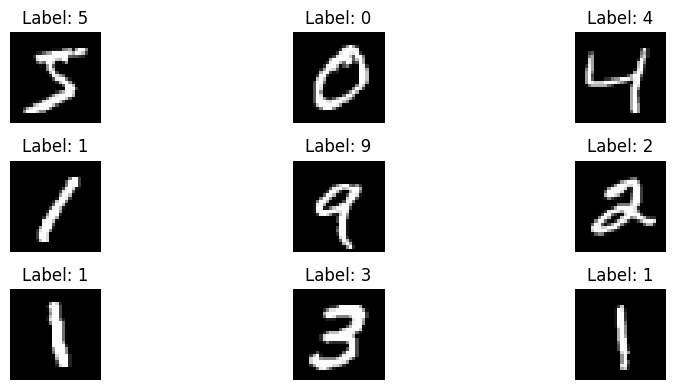

In [3]:
# Visualize sample digits
plt.figure(figsize=(10, 4))
for i in range(9):
    plt.subplot(3, 3, i+1)
    image, label = train_dataset[i]
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [4]:
# Task 2: Design Neural Network

class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Architecture: 784 → 256 → 128 → 10
        # self.network = nn.Sequential(
        #     nn.Flatten(),
        #     nn.Linear(784, 256),
        #     nn.ReLU(),
        #     nn.Linear(256, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, 10)
        # )
        
        # Alternative 1: Larger network
        # self.network = nn.Sequential(
        #     nn.Flatten(),
        #     nn.Linear(784, 512),
        #     nn.ReLU(),
        #     nn.Linear(512, 256),
        #     nn.ReLU(),
        #     nn.Linear(256, 10)
        # )
        
        # Alternative 2: With Dropout (prevents overfitting)
        # self.network = nn.Sequential(
        #     nn.Flatten(),
        #     nn.Linear(784, 256),
        #     nn.ReLU(),
        #     nn.Dropout(0.2),
        #     nn.Linear(256, 128),
        #     nn.ReLU(),
        #     nn.Dropout(0.2),
        #     nn.Linear(128, 10)
        # )
        
        # Alternative 3: Deeper network
        # self.network = nn.Sequential(
        #     nn.Flatten(),
        #     nn.Linear(784, 512),
        #     nn.ReLU(),
        #     nn.Linear(512, 256),
        #     nn.ReLU(),
        #     nn.Linear(256, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, 10)
        # )
        
        # Alternative 4: Simple network
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
        # Alternative 5: High dropout (strong regularization)
        # self.network = nn.Sequential(
        #     nn.Flatten(),
        #     nn.Linear(784, 512),
        #     nn.ReLU(),
        #     nn.Dropout(0.5),
        #     nn.Linear(512, 256),
        #     nn.ReLU(),
        #     nn.Dropout(0.5),
        #     nn.Linear(256, 10)
        # )
    
    def forward(self, x):
        return self.network(x)

model = MNISTNet()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

MNISTNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 101770


In [5]:
# Task 3: Train Neural Network

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 10

all_train_acc = []
all_test_acc = []

print("Training...")

for epoch in range(epochs):
    model.train()
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        outputs = model(images)
        loss = loss_func(outputs, labels)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    
    train_acc = train_correct / train_total
    
    # Test evaluation
    model.eval()
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
    
    test_acc = test_correct / test_total
    
    all_train_acc.append(train_acc)
    all_test_acc.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")


Training...
Epoch 1/10 - Train Acc: 0.8924, Test Acc: 0.9359
Epoch 2/10 - Train Acc: 0.9454, Test Acc: 0.9514
Epoch 3/10 - Train Acc: 0.9595, Test Acc: 0.9620
Epoch 4/10 - Train Acc: 0.9689, Test Acc: 0.9678
Epoch 5/10 - Train Acc: 0.9750, Test Acc: 0.9721
Epoch 6/10 - Train Acc: 0.9798, Test Acc: 0.9731
Epoch 7/10 - Train Acc: 0.9829, Test Acc: 0.9750
Epoch 8/10 - Train Acc: 0.9857, Test Acc: 0.9755
Epoch 9/10 - Train Acc: 0.9877, Test Acc: 0.9763
Epoch 10/10 - Train Acc: 0.9896, Test Acc: 0.9778

Final Test Accuracy: 97.78%


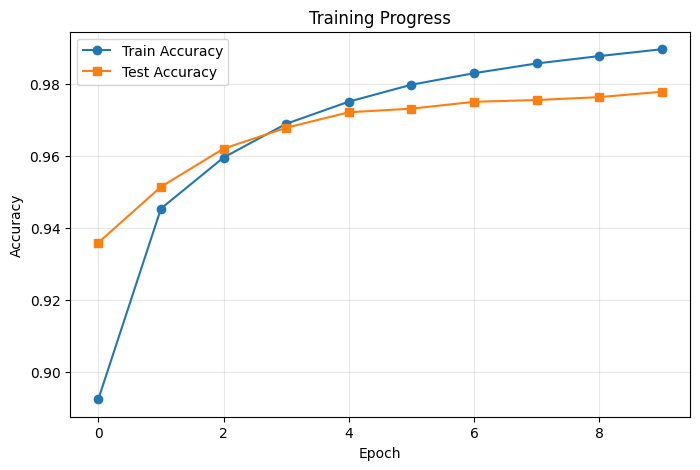

In [6]:
# Visualize training progress
plt.figure(figsize=(8, 5))
plt.plot(all_train_acc, label='Train Accuracy', marker='o')
plt.plot(all_test_acc, label='Test Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
# Task 4: Optimize Architecture with Dropout

class MNISTNetOptimized(nn.Module):
    def __init__(self):
        super().__init__()
        # Architecture: 784 → 512 → 256 → 10 with dropout
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),  # Regularization
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        return self.network(x)

model_opt = MNISTNetOptimized()
optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=0.001)

all_test_acc_opt = []

print("Training optimized model...")

for epoch in range(epochs):
    model_opt.train()
    for images, labels in train_loader:
        outputs = model_opt(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer_opt.step()
        optimizer_opt.zero_grad()
    
    # Test evaluation
    model_opt.eval()
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model_opt(images)
            preds = torch.argmax(outputs, dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
    
    test_acc = test_correct / test_total
    all_test_acc_opt.append(test_acc)
    print(f"Epoch {epoch+1}/{epochs} - Test Acc: {test_acc:.4f}")

print(f"\nOptimized Model Final Accuracy: {test_acc*100:.2f}%")


Training optimized model...
Epoch 1/10 - Test Acc: 0.9605
Epoch 2/10 - Test Acc: 0.9719
Epoch 3/10 - Test Acc: 0.9743
Epoch 4/10 - Test Acc: 0.9793
Epoch 5/10 - Test Acc: 0.9827
Epoch 6/10 - Test Acc: 0.9811
Epoch 7/10 - Test Acc: 0.9806
Epoch 8/10 - Test Acc: 0.9794
Epoch 9/10 - Test Acc: 0.9792
Epoch 10/10 - Test Acc: 0.9806

Optimized Model Final Accuracy: 98.06%


In [8]:
# Task 5: Make Predictions and Analyze Results

# Get predictions on test set
model_opt.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_opt(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Find correct and incorrect predictions
correct_indices = np.where(all_preds == all_labels)[0]
incorrect_indices = np.where(all_preds != all_labels)[0]

print(f"Correct predictions: {len(correct_indices)}/{len(all_labels)}")
print(f"Incorrect predictions: {len(incorrect_indices)}/{len(all_labels)}")


Correct predictions: 9806/10000
Incorrect predictions: 194/10000


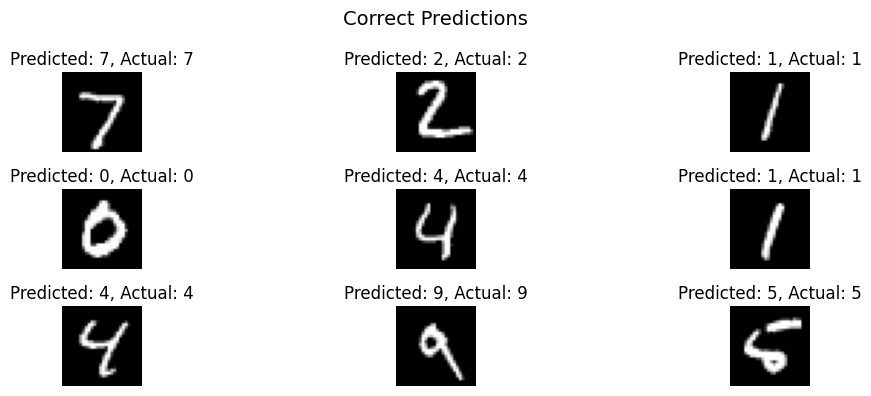

In [9]:
# Visualize correct predictions
plt.figure(figsize=(12, 4))
for i in range(9):
    plt.subplot(3, 3, i+1)
    idx = correct_indices[i]
    image, label = test_dataset[idx]
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Predicted: {all_preds[idx]}, Actual: {all_labels[idx]}")
    plt.axis('off')
plt.suptitle("Correct Predictions", fontsize=14)
plt.tight_layout()
plt.show()


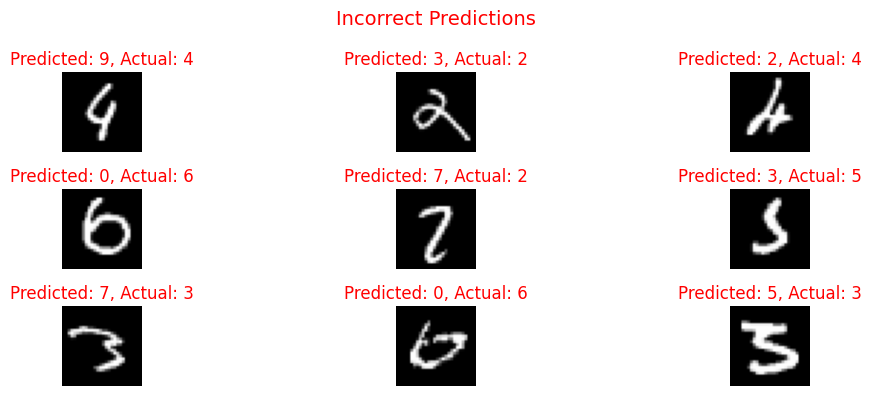

In [10]:
# Visualize incorrect predictions
plt.figure(figsize=(12, 4))
for i in range(min(9, len(incorrect_indices))):
    plt.subplot(3, 3, i+1)
    idx = incorrect_indices[i]
    image, label = test_dataset[idx]
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Predicted: {all_preds[idx]}, Actual: {all_labels[idx]}", color='red')
    plt.axis('off')
plt.suptitle("Incorrect Predictions", fontsize=14, color='red')
plt.tight_layout()
plt.show()


DIGIT PREDICTION
Predicted digit: 4
Actual digit: 4
Prediction correct: True

Confidence: 100.00%

All class probabilities:
  Digit 0: 0.00%
  Digit 1: 0.00%
  Digit 2: 0.00%
  Digit 3: 0.00%
  Digit 4: 100.00%
  Digit 5: 0.00%
  Digit 6: 0.00%
  Digit 7: 0.00%
  Digit 8: 0.00%
  Digit 9: 0.00%


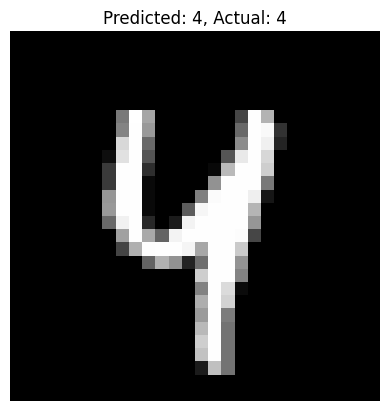

In [11]:
# Task 6: Test on Specific Digit

test_idx = 42  # Try different indices
image, true_label = test_dataset[test_idx]

model_opt.eval()
with torch.no_grad():
    output = model_opt(image.unsqueeze(0))  # Add batch dimension
    probs = torch.softmax(output, dim=1)
    pred_label = torch.argmax(output, dim=1).item()

print("=" * 60)
print("DIGIT PREDICTION")
print("=" * 60)
print(f"Predicted digit: {pred_label}")
print(f"Actual digit: {true_label}")
print(f"Prediction correct: {pred_label == true_label}")
print(f"\nConfidence: {probs[0][pred_label].item()*100:.2f}%")
print("\nAll class probabilities:")
for i in range(10):
    print(f"  Digit {i}: {probs[0][i].item()*100:.2f}%")
print("=" * 60)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {pred_label}, Actual: {true_label}")
plt.axis('off')
plt.show()



SUMMARY
Original Model (256→128):     97.78%
Optimized Model (512→256+Dropout): 98.06%


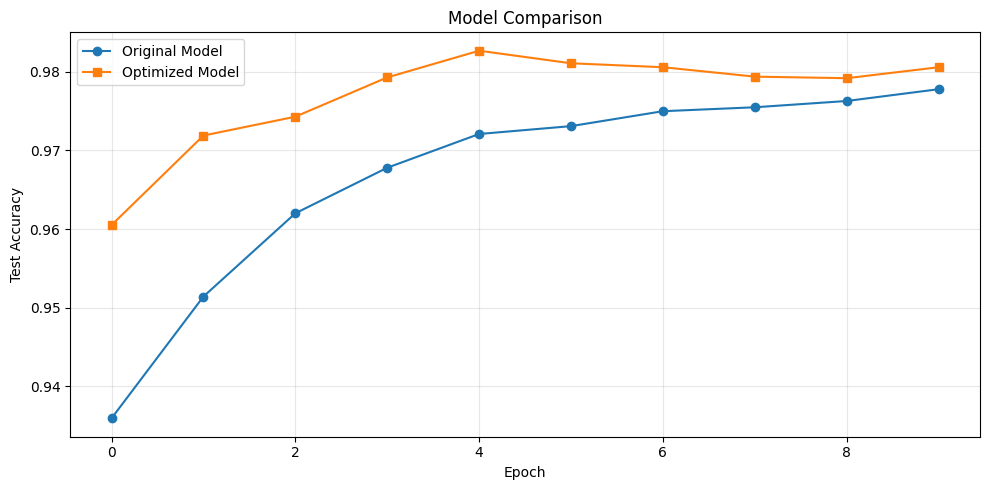

In [12]:
# Summary: Compare Models and Answer Questions

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Original Model (256→128):     {all_test_acc[-1]*100:.2f}%")
print(f"Optimized Model (512→256+Dropout): {all_test_acc_opt[-1]*100:.2f}%")
print("=" * 60)

# Compare models
plt.figure(figsize=(10, 5))
plt.plot(all_test_acc, label='Original Model', marker='o')
plt.plot(all_test_acc_opt, label='Optimized Model', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
